<a href="https://colab.research.google.com/github/UjjvalDE/AI/blob/main/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train shape: (60000, 28, 28)
Test shape : (10000, 28, 28)


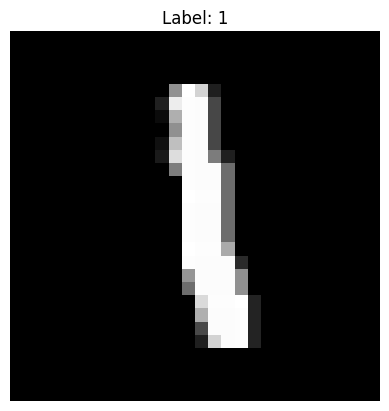

In [3]:
plt.imshow(X_train[6], cmap="gray")
plt.title(f"Label: {y_train[6]}")
plt.axis("off")
plt.show()


In [4]:
X_train = X_train / 255.0
X_test  = X_test  / 255.0

In [5]:
X_train = X_train.reshape(-1, 28 * 28)
X_test  = X_test.reshape(-1, 28 * 28)
print("Flattened train shape:", X_train.shape)
print("Flattened test shape :", X_test.shape)


Flattened train shape: (60000, 784)
Flattened test shape : (10000, 784)


In [6]:
def build_mlp(activation_hidden):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation=activation_hidden),
        tf.keras.layers.Dense(128, activation=activation_hidden),
        tf.keras.layers.Dense(64,  activation=activation_hidden),
        tf.keras.layers.Dense(64,  activation=activation_hidden),
        tf.keras.layers.Dense(32,  activation=activation_hidden),
        tf.keras.layers.Dense(32,  activation=activation_hidden),
        tf.keras.layers.Dense(10,  activation='softmax')  # 10 classes, probability distribution
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [7]:
model_sigmoid = build_mlp('sigmoid')
print("Model with Sigmoid hidden layers:")
model_sigmoid.summary()

history_sigmoid = model_sigmoid.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

test_loss_sig, test_acc_sig = model_sigmoid.evaluate(X_test, y_test, verbose=0)
print(f"[Sigmoid] Test accuracy: {test_acc_sig:.4f}, Test loss: {test_loss_sig:.4f}")


Model with Sigmoid hidden layers:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,874 (519.04 KB)

 Trainable params: 132,874 (519.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.2130 - loss: 2.1501 - val_accuracy: 0.5692 - val_loss: 1.2255
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6149 - loss: 1.1192 - val_accuracy: 0.7605 - val_loss: 0.8373
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7932 - loss: 0.7711 - val_accuracy: 0.8428 - val_loss: 0.5697
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8688 - loss: 0.5180 - val_accuracy: 0.9028 - val_loss: 0.4182
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9108 - loss: 0.3797 - val_accuracy: 0.9209 - val_loss: 0.3289
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9378 - loss: 0.2825 - val_accuracy: 0.9367 - val_loss: 0.2619
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9451 - loss: 0.2349 - val_accuracy: 0.9436 - val_loss: 0.2278
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9545 - loss: 0.1966 - val_accuracy: 0.

In [8]:
model_tanh = build_mlp('tanh')
print("Model with Tanh hidden layers:")
model_tanh.summary()

history_tanh = model_tanh.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

test_loss_tanh, test_acc_tanh = model_tanh.evaluate(X_test, y_test, verbose=0)
print(f"[Tanh]    Test accuracy: {test_acc_tanh:.4f}, Test loss: {test_loss_tanh:.4f}")

Model with Tanh hidden layers:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,874 (519.04 KB)

 Trainable params: 132,874 (519.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8176 - loss: 0.7057 - val_accuracy: 0.9442 - val_loss: 0.1964
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9483 - loss: 0.1778 - val_accuracy: 0.9536 - val_loss: 0.1589
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9633 - loss: 0.1250 - val_accuracy: 0.9587 - val_loss: 0.1389
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9742 - loss: 0.0878 - val_accuracy: 0.9653 - val_loss: 0.1179
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9787 - loss: 0.0711 - val_accuracy: 0.9670 - val_loss: 0.1194
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9829 - loss: 0.0576 - val_accuracy: 0.9698 - val_loss: 0.1058
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9863 - loss: 0.0461 - val_accuracy: 0.9687 - val_loss: 0.1111
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9869 - loss: 0.0415 - val_accuracy: 0.

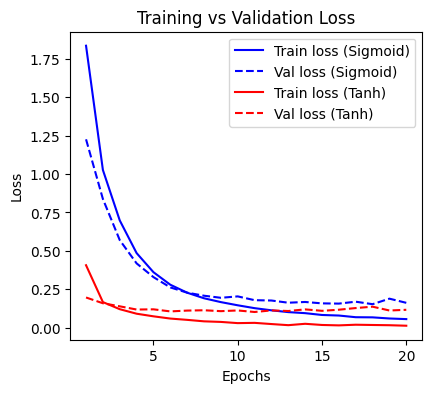

In [9]:
epochs_sig = range(1, len(history_sigmoid.history['loss']) + 1)
epochs_tanh = range(1, len(history_tanh.history['loss']) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_sig, history_sigmoid.history['loss'], 'b-', label='Train loss (Sigmoid)')
plt.plot(epochs_sig, history_sigmoid.history['val_loss'], 'b--', label='Val loss (Sigmoid)')
plt.plot(epochs_tanh, history_tanh.history['loss'], 'r-', label='Train loss (Tanh)')
plt.plot(epochs_tanh, history_tanh.history['val_loss'], 'r--', label='Val loss (Tanh)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()


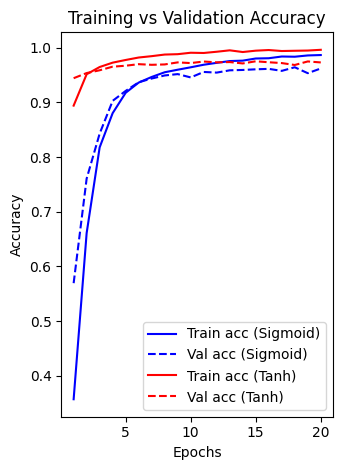

In [10]:
plt.subplot(1, 2, 2)
plt.plot(epochs_sig, history_sigmoid.history['accuracy'], 'b-', label='Train acc (Sigmoid)')
plt.plot(epochs_sig, history_sigmoid.history['val_accuracy'], 'b--', label='Val acc (Sigmoid)')
plt.plot(epochs_tanh, history_tanh.history['accuracy'], 'r-', label='Train acc (Tanh)')
plt.plot(epochs_tanh, history_tanh.history['val_accuracy'], 'r--', label='Val acc (Tanh)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [11]:
print("\n==== FINAL TEST PERFORMANCE ====")
print(f"Sigmoid -> accuracy: {test_acc_sig:.4f}, loss: {test_loss_sig:.4f}")
print(f"Tanh    -> accuracy: {test_acc_tanh:.4f}, loss: {test_loss_tanh:.4f}")


==== FINAL TEST PERFORMANCE ====
Sigmoid -> accuracy: 0.9612, loss: 0.1772
Tanh    -> accuracy: 0.9730, loss: 0.1176
